In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.manifold import TSNE
import umap
import trimap
import pacmap
import warnings
from scipy.cluster.hierarchy import linkage, dendrogram


warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

RANDOM_STATE=318


In [17]:
def analyze_dataset(df, name, target_col=None):
    print(f"\n--- DATASET: {name} ---")

    X = df.copy()
    y_true = None

    if target_col is not None:
        if isinstance(target_col, int):
            y_true = X.iloc[:, target_col]
            X = X.drop(X.columns[target_col], axis=1)
        else:
            if target_col in X.columns:
                y_true = X[target_col]
                X = X.drop(columns=[target_col])

        if y_true is not None and y_true.dtype == 'object':
            y_true = LabelEncoder().fit_transform(y_true)

    for col in X.columns:
        if X[col].dtype == 'object':
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    X = X.fillna(X.mean())

    if len(X) > 5000:
        X = X.sample(5000, random_state=RANDOM_STATE)
        if y_true is not None:
            y_true = y_true[X.index]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    inertia = []
    sil_km = []
    sil_agg = []
    K = range(2, 10)

    for k in K:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels_km = km.fit_predict(X_scaled)
        inertia.append(km.inertia_)
        sil_km.append(silhouette_score(X_scaled, labels_km))

        agg = AgglomerativeClustering(n_clusters=k)
        labels_agg = agg.fit_predict(X_scaled)
        sil_agg.append(silhouette_score(X_scaled, labels_agg))

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    ax[0].plot(K, inertia, 'bo-')
    ax[0].set_title('Elbow Method')
    ax[1].plot(K, sil_km, 'go-', label='KMeans')
    ax[1].plot(K, sil_agg, 'rx--', label='Agglomerative')
    ax[1].set_title('Silhouette Score')
    ax[1].legend()
    plt.show()

    best_k = K[np.argmax(sil_km)]
    print(f"Best k: {best_k}")

    model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)

    if y_true is not None:
        print(f"ARI: {adjusted_rand_score(y_true, labels):.4f}")

    centers = model.cluster_centers_

    embedding_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    n_iter=1500,
    init='pca',
    random_state=RANDOM_STATE,
    ).fit_transform(X_scaled)

    embedding_umap = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    random_state=RANDOM_STATE
    ).fit_transform(X_scaled)

    embedding_trimap = trimap.TRIMAP(
    n_inliers=20,
    n_outliers=10,
    n_iters=500,
).fit_transform(X_scaled)

    embedding_pacmap = pacmap.PaCMAP(
    n_components=2,
    MN_ratio=0.5,
    FP_ratio=2.0,
    random_state=RANDOM_STATE
    ).fit_transform(X_scaled)

    pca_for_centers = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_scaled)
    centers_2d = pca_for_centers.transform(centers)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    def plot_with_centers(ax, emb, title):
        sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=labels, palette='viridis', ax=ax, s=25)
        ax.scatter(centers_2d[:, 0], centers_2d[:, 1], c='white', edgecolors='black',
                   marker='X', s=200, linewidths=1.8, zorder=10)
        ax.set_title(title)

    plot_with_centers(axes[0, 0], embedding_tsne, 't-SNE')
    plot_with_centers(axes[0, 1], embedding_umap, 'UMAP')
    plot_with_centers(axes[1, 0], embedding_trimap, 'TriMAP')
    plot_with_centers(axes[1, 1], embedding_pacmap, 'PaCMAP')

    plt.tight_layout()
    plt.show()
    # print("\nDendrogram (Hierarchical Clustering):")
    # Z = linkage(X_scaled, method='ward')
    # plt.figure(figsize=(14, 6))
    # dendrogram(Z, truncate_mode='level', p=5, color_threshold=None)
    # plt.title(f"Dendrogram ({name})")
    # plt.xlabel("Samples / Cluster merges")
    # plt.ylabel("Distance")
    # plt.show()


--- DATASET: Soybean Large ---


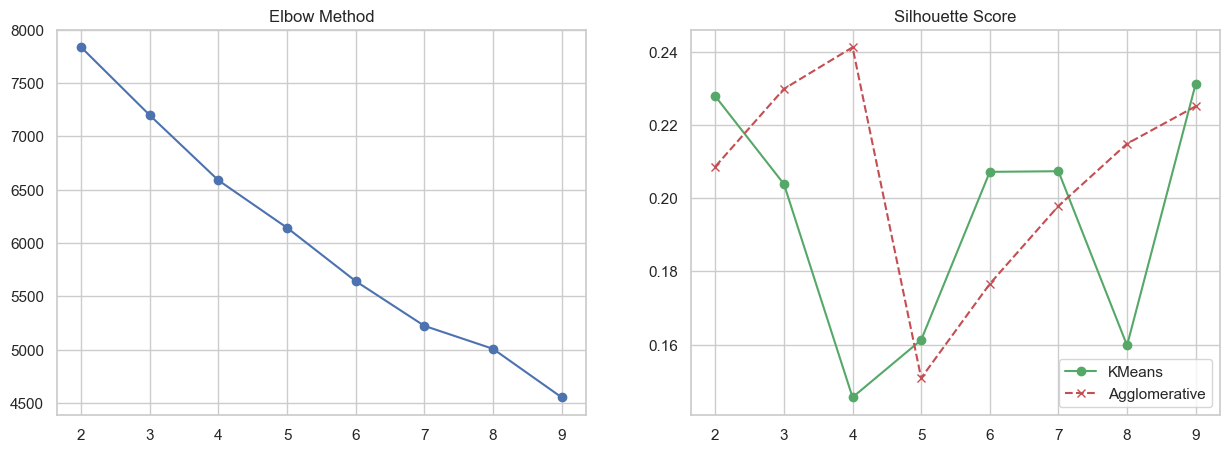

Best k: 9
ARI: 0.3517


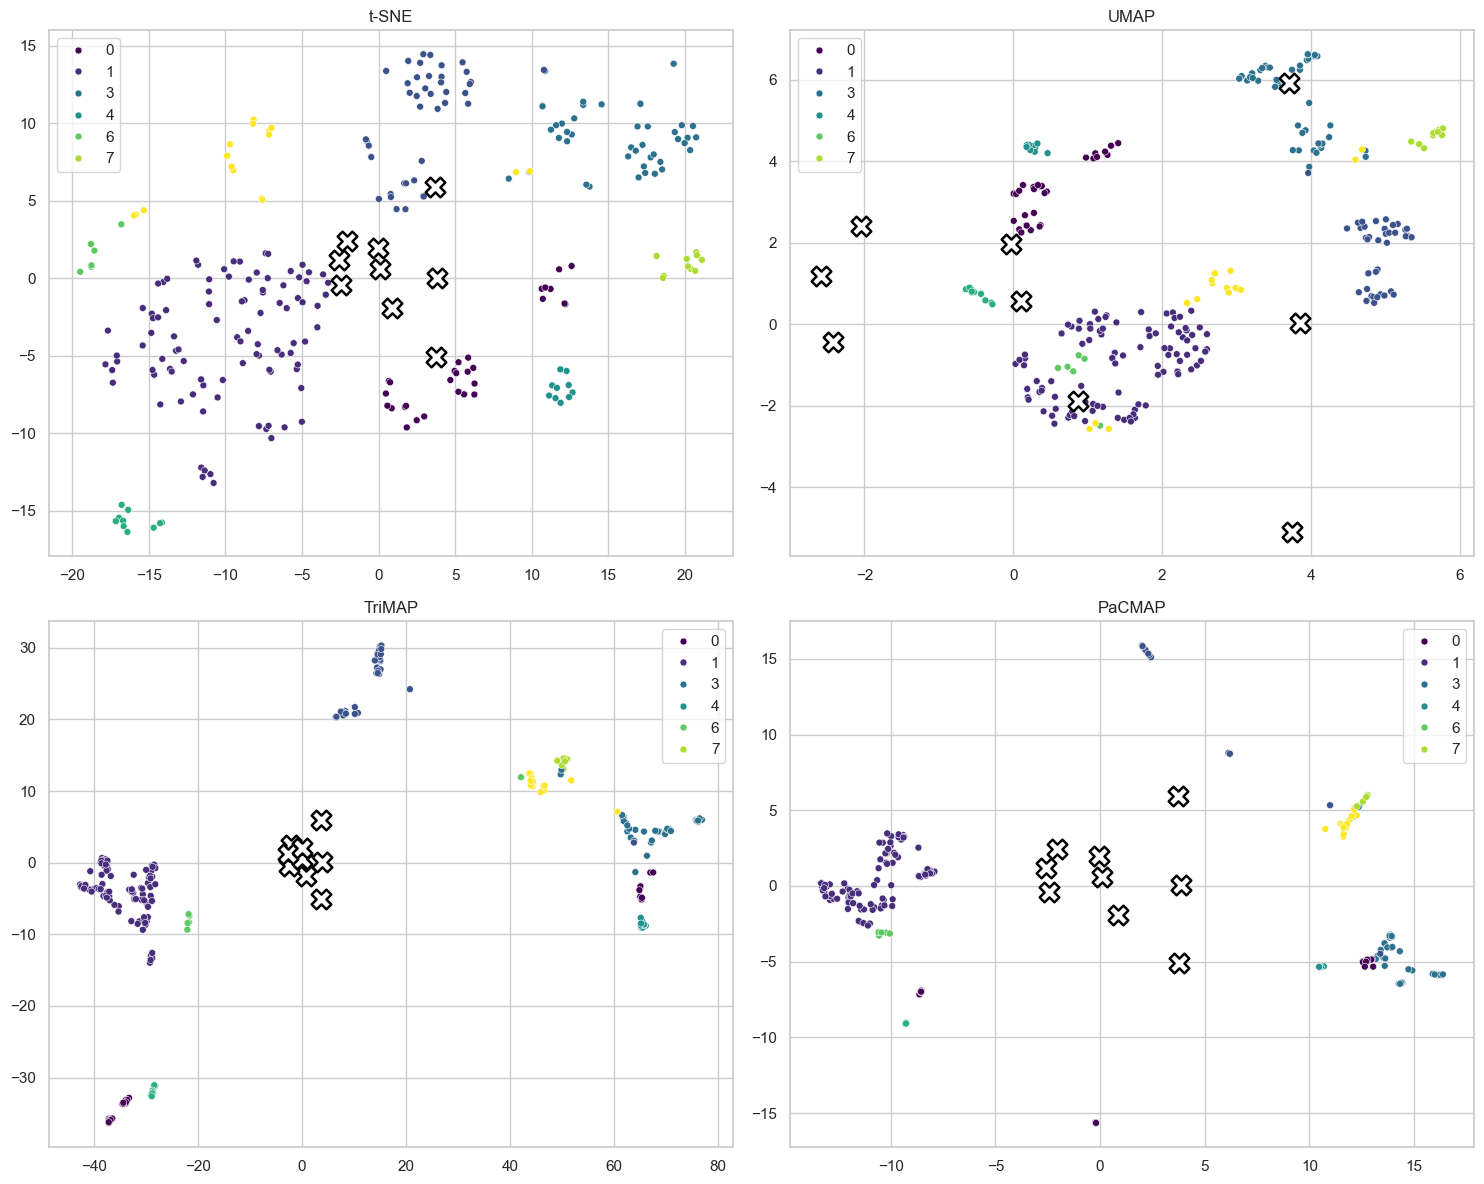

In [18]:
df_soy = pd.read_csv('soybean-large.data', header=None)
df_soy = df_soy.replace('?', np.nan).dropna()
analyze_dataset(df_soy, "Soybean Large", target_col=0)


--- DATASET: Benign Traffic ---


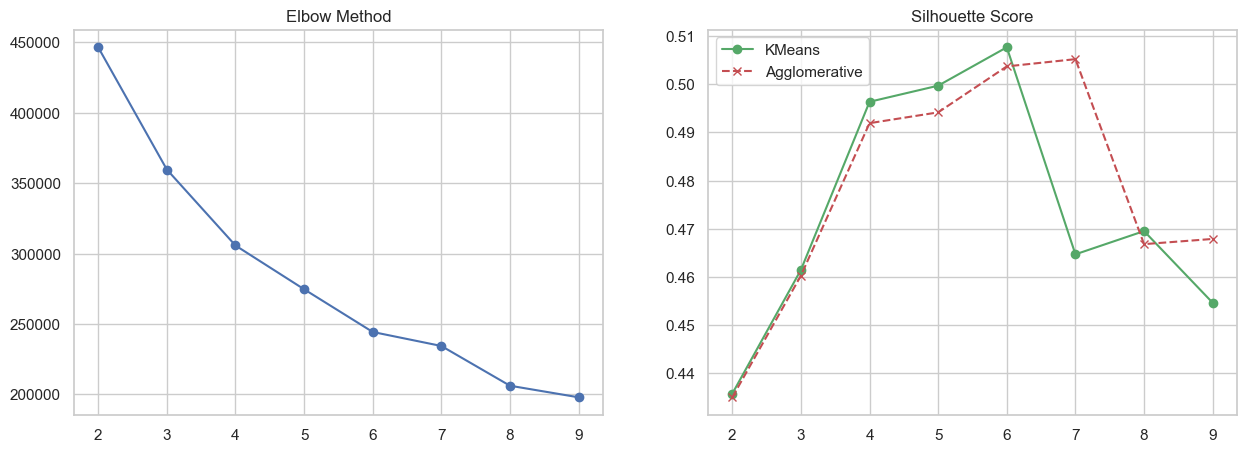

Best k: 6


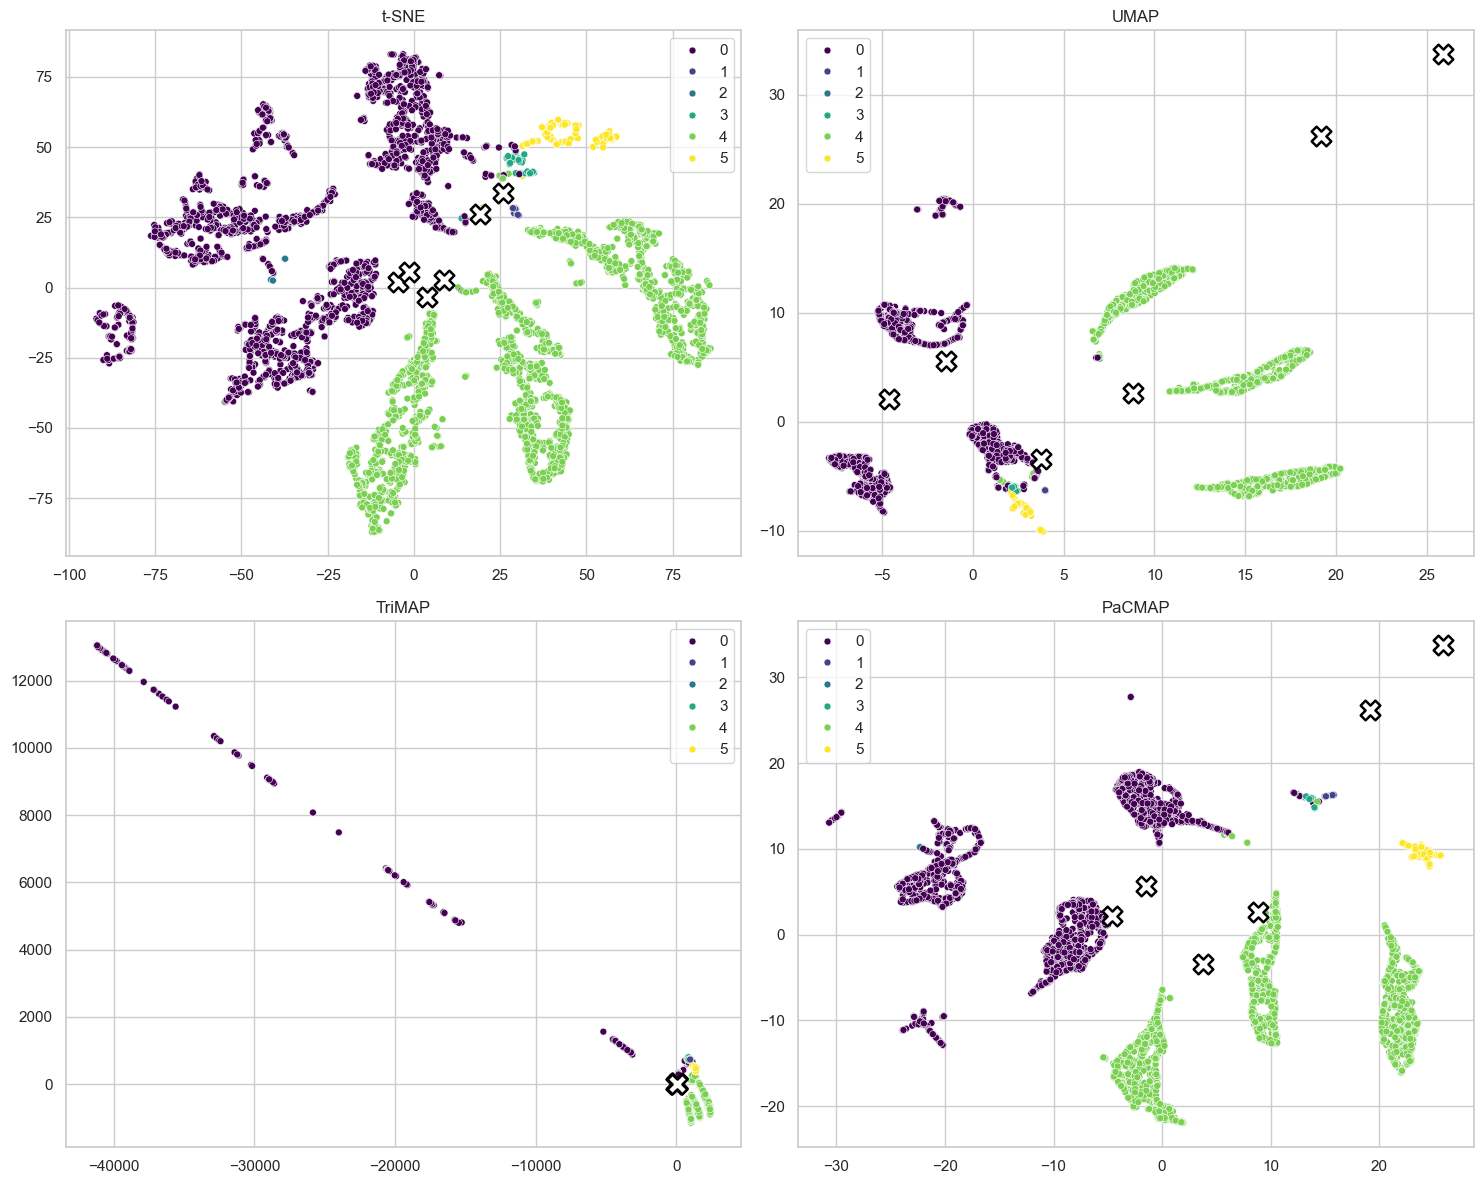

In [19]:
df_traffic = pd.read_csv('benign_traffic.csv')
analyze_dataset(df_traffic, "Benign Traffic")


--- DATASET: Mammoth ---


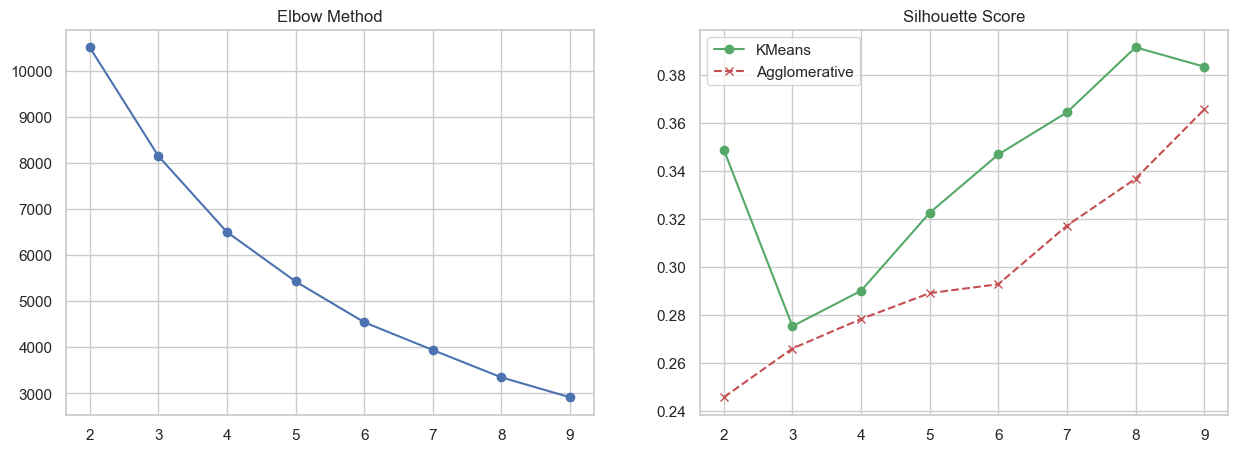

Best k: 8


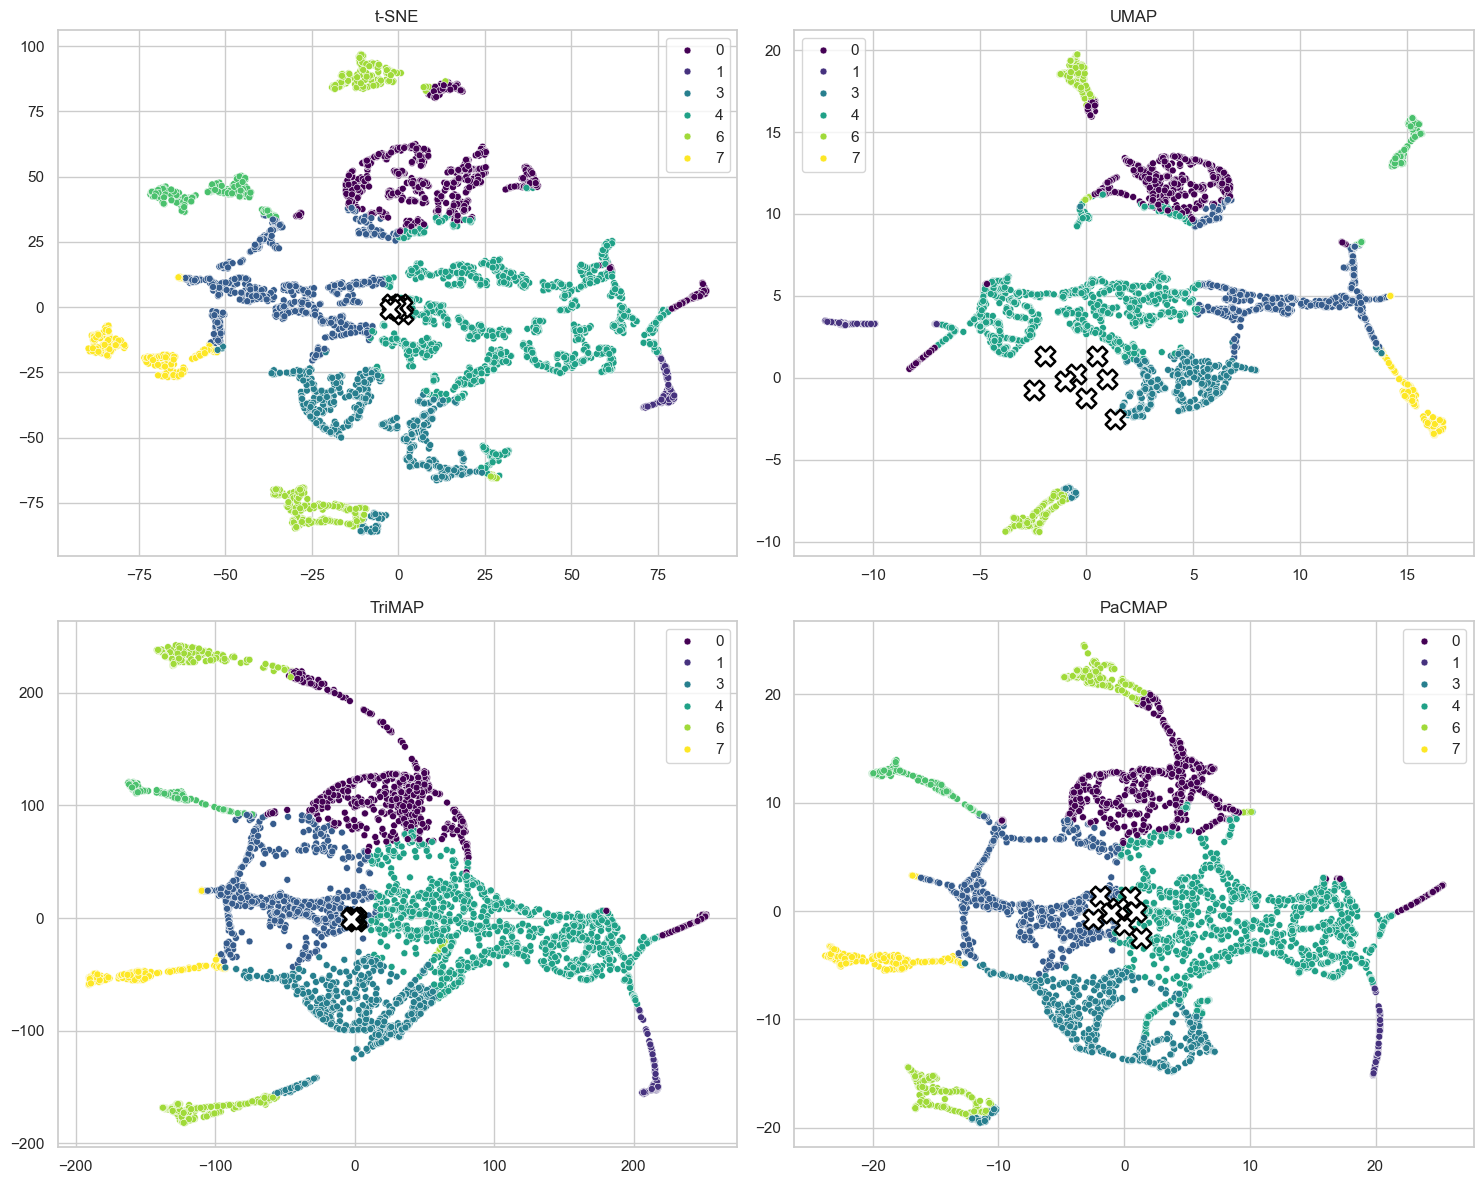

In [20]:
df_mammoth = pd.read_csv('mammoth.csv')
analyze_dataset(df_mammoth, "Mammoth")